##### ***网络中的网络NiN***
###### LeNet、AlexNet和VGG都有一个共同的设计模式：通过卷积层和池化层提取空间结构特征，然后通过全连接层对特征的表征进行处理。然而使用全连接层会导致空间结构信息的丢失，而NiN则提出了一种不同的设计模式：使用1x1卷积层来替代全连接层，从而保留空间结构信息。
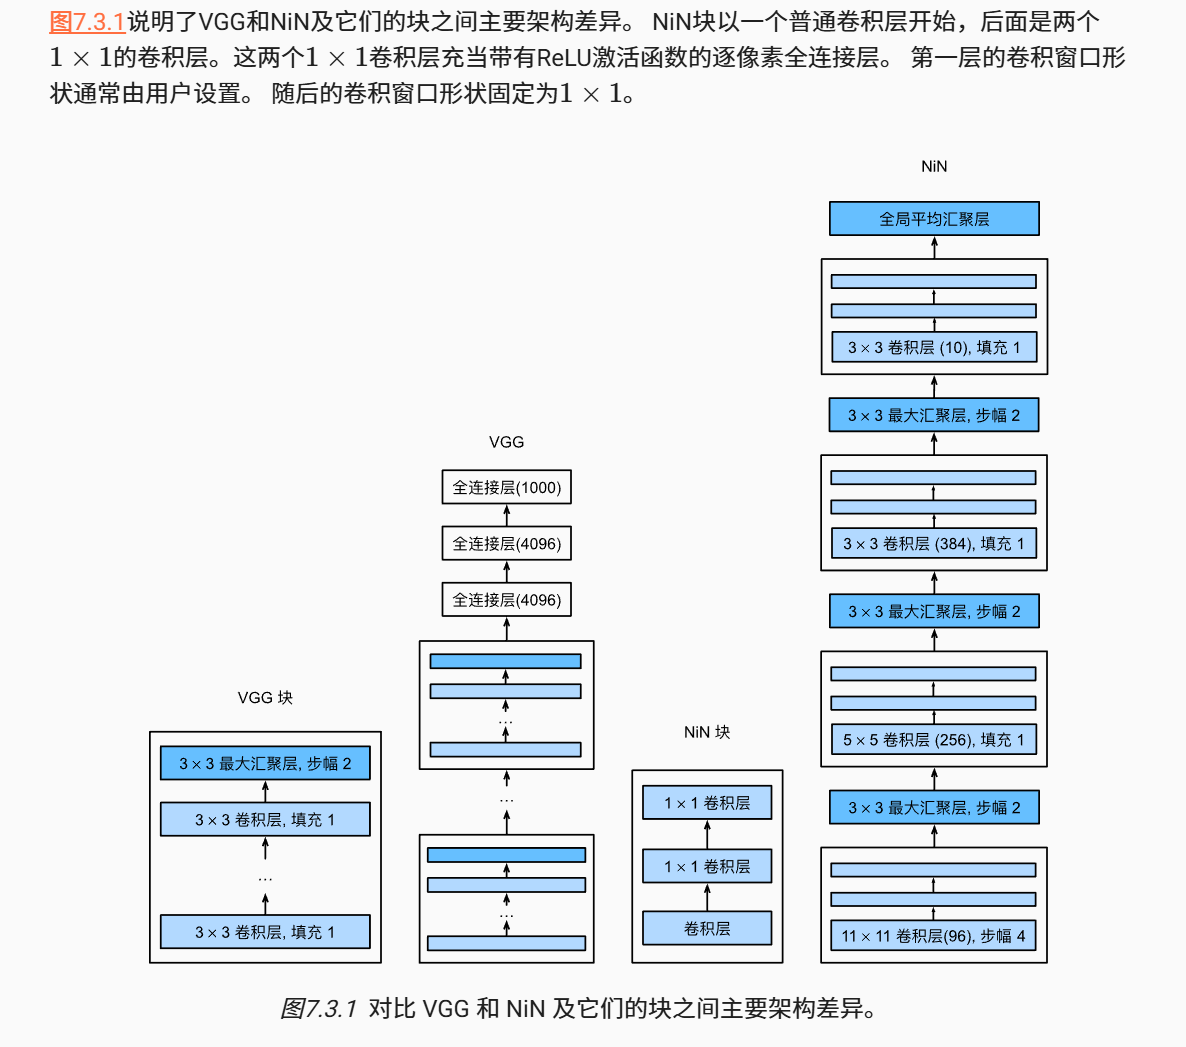
###### 总体来说NiN的架构无全连接层；交替使用NiN块和步幅为2的最大池化层逐步减小高宽和增大通道数，最后使用全局平均池化层得到输出。

In [1]:
import torch
from torch import nn
from d2l import torch as d2l

def nin_block(in_channels, out_channels,kernel_size, strides, padding):
    return nn.Sequential(
        nn.Conv2d(in_channels, out_channels, kernel_size, strides, padding),
        nn.ReLU(),
        nn.Conv2d(out_channels, out_channels, kernel_size=1),
        nn.ReLU(),
        nn.Conv2d(out_channels, out_channels, kernel_size=1),
        nn.ReLU()
    )

In [2]:
net = nn.Sequential(
    nin_block(1, 96, 11, 4, 0),
    nn.MaxPool2d(3, 2),
    nin_block(96, 256, 5, 1, 2),
    nn.MaxPool2d(3, 2),
    nin_block(256, 384, 3, 1, 1),
    nn.MaxPool2d(3, 2),
    nn.Dropout(0.5),
    nin_block(384, 10, 3, 1, 1),
    nn.AdaptiveAvgPool2d((1, 1)),
    # 将四维的输出转成二维的输出，其形状为(批量大小,10)
    nn.Flatten()
)

In [3]:
X = torch.rand(size=(1, 1, 224, 224))
for layer in net:
    X = layer(X)
    print(layer.__class__.__name__,'output shape:\t', X.shape)

Sequential output shape:	 torch.Size([1, 96, 54, 54])
MaxPool2d output shape:	 torch.Size([1, 96, 26, 26])
Sequential output shape:	 torch.Size([1, 256, 26, 26])
MaxPool2d output shape:	 torch.Size([1, 256, 12, 12])
Sequential output shape:	 torch.Size([1, 384, 12, 12])
MaxPool2d output shape:	 torch.Size([1, 384, 5, 5])
Dropout output shape:	 torch.Size([1, 384, 5, 5])
Sequential output shape:	 torch.Size([1, 10, 5, 5])
AdaptiveAvgPool2d output shape:	 torch.Size([1, 10, 1, 1])
Flatten output shape:	 torch.Size([1, 10])


training on cpu


KeyboardInterrupt: 

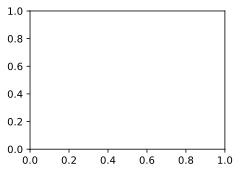

In [4]:
lr, num_epochs, batch_size = 0.1, 10, 128
train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size, resize=224)
d2l.train_ch6(net, train_iter, test_iter, num_epochs, lr, d2l.try_gpu())

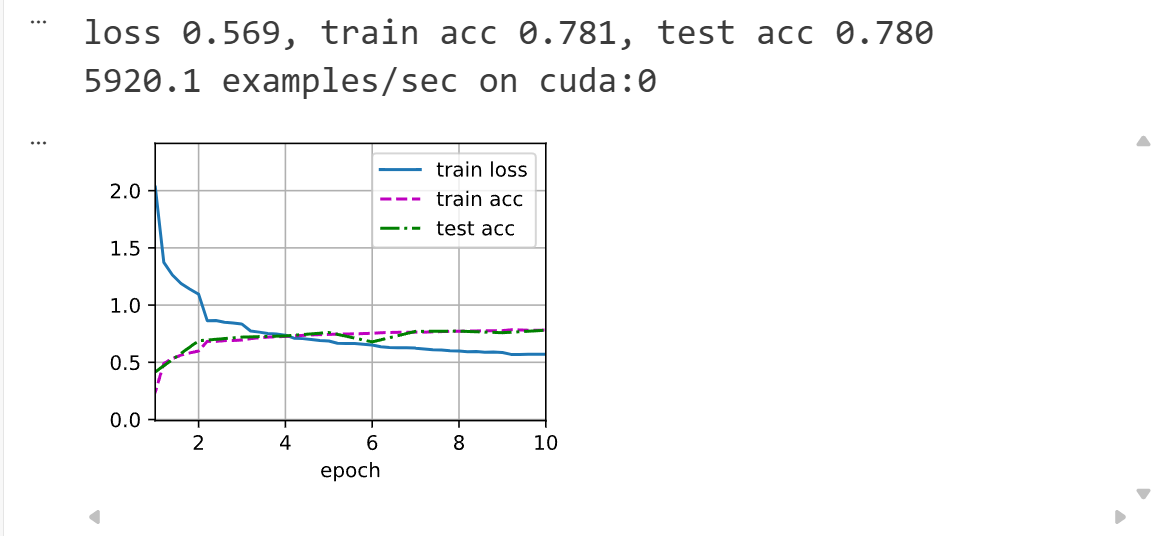